In [1]:
import torch, os, cv2, re
import scipy.io as sio
import numpy as np
import pandas as pd

from PIL import Image, ImageDraw, ImageFont

In [2]:
from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()

def min_max_normalize(arr):
    arr = np.array(arr)
    arr_min = arr.min()
    arr_max = arr.max()
    if arr_max - arr_min == 0:
        return np.zeros_like(arr)
    return (arr - arr_min) / (arr_max - arr_min)

In [3]:
import json, random, csv, time, os, random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import pandas as pd
from datetime import datetime
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt
from collections import defaultdict
import torchvision.transforms as T

# Load data
with open("../../data/coco_caption_concereteness_with_lemmatization.json") as f:
    data = json.load(f)

for i, img in enumerate(data):
    max_score, min_score = 0, 100
    max_id, min_id = 0, 0
    for c, cap in enumerate(img['caption_concreteness']):
        mean_score = mean(cap['concreteness'])
        data[i]['caption_concreteness'][c]['concrete_score'] = mean_score
        data[i]['caption_concreteness'][c]['abstract_score'] = mean_score
        if mean_score > max_score:
            max_score = mean_score
            max_id = cap['id']
        if mean_score < min_score:
            min_score = mean_score
            min_id = cap['id']
    data[i]['concrete_abstact_diff'] = {
        'value' : max_score - min_score,
        'ids': [max_id, min_id],
}

all_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var", "abstract_score", "concrete_score"]
test_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var"]

# Filter entries with both concrete and abstract ids
filtered_data = [item for item in data if len(set(item['concrete_abstact_diff']['ids'])) > 1]
filtered_data = sorted(filtered_data, key=lambda x: x['concrete_abstact_diff']['value'], reverse=True)

def extract_attr_lists(data_subset):
    ids = []
    abs_captions = []
    con_captions = []
    value_diffs = []
    abs_vals = {attr: [] for attr in all_attributes}
    con_vals = {attr: [] for attr in all_attributes}

    for entry in data_subset:
        ids.append(entry['image'])
        value_diffs.append(entry['concrete_abstact_diff']['value'])
        con_id, abs_id = entry['concrete_abstact_diff']['ids']
        con_cap = next(c for c in entry['caption_concreteness'] if c['id'] == con_id)
        abs_cap = next(c for c in entry['caption_concreteness'] if c['id'] == abs_id)

        abs_captions.append(abs_cap)
        con_captions.append(con_cap)

        for attr in ["concrete_score", "abstract_score"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        if 'char_number' in all_attributes:
            abs_vals['char_number'].append(len(abs_cap['caption']))
            con_vals['char_number'].append(len(con_cap['caption']))

        if 'word_number' in all_attributes:
            abs_vals['word_number'].append(len(abs_cap['caption'].split(' ')))
            con_vals['word_number'].append(len(con_cap['caption'].split(' ')))

        for attr in ["matching_score", "emap_var"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        for attr in ["word_importances", "word_frequency"]:
            if attr in all_attributes:
                abs_vals[attr].append(mean(abs_cap[attr]))
                con_vals[attr].append(mean(con_cap[attr]))

    return ids, value_diffs, abs_captions, con_captions, abs_vals, con_vals

ids_all, value_diffs_all, _, _, abs_vals_all, con_vals_all = extract_attr_lists(filtered_data)

experiment = '20250723_193742'

selected_indices = []
saved = pd.read_csv(f"../../stimuli/250602-250723_stimuli_average/{experiment}/captions_and_attributes.csv")
saved_ids = saved['image_id'].tolist()
for e, entry in enumerate(filtered_data):
    if entry['image'] in saved_ids:
        selected_indices.append(e)

selected_indices.sort()
selected_entries = [filtered_data[idx] for idx in selected_indices]

ids_selected, value_diffs_selected, abs_captions_selected, con_captions_selected, abs_vals_selected, con_vals_selected = extract_attr_lists(selected_entries)

In [4]:
analysis_name = "251104_lextale60"
data_all = pd.DataFrame()

### Word Importance Vector Generation

In [5]:
for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected, abs_captions_selected, con_captions_selected)):
    # Load image
    img_path = f"../../results/{analysis_name}/human/image/images/matched_abs_{image_id.split('/')[-1]}"

    abs_emap = torch.load(f"../../data/emaps_resized/{image_id.split('_')[-1].split('.')[0]}_{abs_cap['id']}.pt", map_location="cpu")
    con_emap = torch.load(f"../../data/emaps_resized/{image_id.split('_')[-1].split('.')[0]}_{con_cap['id']}.pt", map_location="cpu")

    img = Image.open(img_path).convert("RGB")
    h, w = img.size
    resize = T.Resize((w,h))

    emaps =resize(torch.stack([abs_emap, con_emap], dim=0))

    abs_emap = emaps[0].numpy()
    con_emap = emaps[1].numpy()

    for con, cap, map in zip(['abs', 'con'], [abs_cap, con_cap], [abs_emap, con_emap]):
        human_map = torch.load(f"../../results/{analysis_name}/human/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        grp1_map = torch.load(f"../../results/{analysis_name}/grp1/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        grp2_map = torch.load(f"../../results/{analysis_name}/grp2/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()

        data_all = pd.concat([data_all, pd.DataFrame([{
            "condition": con,
            "image_id": image_id,
            "caption": cap['caption'],
            "caption_words": [re.sub(r'[^\w\s]', '', tok) for tok in cap['caption'].split()],
            "concreteness": cap["concreteness"],
            "concrete_score": mean(cap['concreteness']),
            "target_words": cap["words"],
            "clip_map": map,
            "human_map": human_map,
            "grp1_map": grp1_map,
            "grp2_map": grp2_map,
            "clip_word_importance": cap['word_importances'],
            "human_word_importance": None,
            "grp1_word_importance": None,
            "grp2_word_importance": None,
        }], index=[f"matched_{con}_{image_id.split('/')[-1]}"])], ignore_index=False)

In [ ]:
import ast 

image_info_segmentation = pd.read_csv("../../stimuli/250619-250723_stimuli_experiment/20250723_193742/image_info_segmentation.csv")

for _, row in image_info_segmentation.iterrows():
    trial_id = row['trial_id']

    if "mismatched" in trial_id:
        continue  

    word_spans = ast.literal_eval(row['word_spans'])

    for group in ['human', 'grp1', 'grp2']:  

        fixations = pd.read_excel(f"../../results/{analysis_name}/{group}/whole_screen/fixations/{trial_id}.xlsx")

        num_fixations = []

        for span in word_spans:
            x1, x2, y1, y2 = span

            # Filter fixations within the bounding box
            y1 = 1024 - y1
            y2 = 1024 - y2
            y1, y2 = y2, y1

            num_fixs = np.sum((fixations['CURRENT_FIX_X'] >= x1) & (fixations['CURRENT_FIX_X'] <= x2) &
                            (fixations['CURRENT_FIX_Y'] >= y1) & (fixations['CURRENT_FIX_Y'] <= y2))
            
            num_fixations.append(num_fixs)

        # Min-max normalization for num_fixations
        data_all.at[trial_id, f'{group}_word_importance'] = (np.array(num_fixations) - np.min(num_fixations)) / (np.max(num_fixations) - np.min(num_fixations))

### Calculate PCC (Alignment Scores)

In [7]:
for group in ['human', 'grp1', 'grp2']:
    for trial_id, info in data_all.iterrows():
        data_all.at[trial_id, f'{group}_map_pcc'] = np.corrcoef(info['clip_map'].flatten(), info[f'{group}_map'].flatten())[0, 1]
        # only words with concreteness ratings
        data_all.at[trial_id, f'{group}_word_importance_pcc'] = np.corrcoef(info['clip_word_importance'], info[f'{group}_word_importance'])[0, 1]
        data_all.at[trial_id, f'{group}_concatenate_pcc'] = np.corrcoef(
            np.concatenate([info['clip_map'].flatten(), info['clip_word_importance']]),
            np.concatenate([info[f'{group}_map'].flatten(), info[f'{group}_word_importance']])
        )[0, 1]

### Statistical Analysis

Paired t test (by image item) comparing CLIP-human alignment in concrete vs abstract conditions

In [24]:
# T-test analysis
for group in ['human', 'grp1', 'grp2']:
    print(f"Group: {group}")
    for measurement in [f'{group}_map_pcc', f'{group}_word_importance_pcc', f'{group}_concatenate_pcc']:
        con_pcc_scores = [info[measurement] for trial_id, info in data_all.iterrows() if info['condition'] == 'con']
        abs_pcc_scores = [info[measurement] for trial_id, info in data_all.iterrows() if info['condition'] == 'abs']

        # Perform t-test
        t_stat, p_value = ttest_rel(con_pcc_scores, abs_pcc_scores)

        print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

Group: human
(human_map_pcc) T-statistic: -0.29234174075842534, P-value: 0.7707917492811607
(human_word_importance_pcc) T-statistic: 2.0427954463730185, P-value: 0.04440785998109138
(human_concatenate_pcc) T-statistic: -0.2916432269712574, P-value: 0.7713238607142109
Group: grp1
(grp1_map_pcc) T-statistic: -0.34453442443020527, P-value: 0.7313599134451229
(grp1_word_importance_pcc) T-statistic: 1.7483758014458568, P-value: 0.08428370422420303
(grp1_concatenate_pcc) T-statistic: -0.3439439436824381, P-value: 0.7318022300107445
Group: grp2
(grp2_map_pcc) T-statistic: -0.3818574778673187, P-value: 0.7035923133317876
(grp2_word_importance_pcc) T-statistic: 3.187056512484489, P-value: 0.0020594883117541173
(grp2_concatenate_pcc) T-statistic: -0.3808789136624779, P-value: 0.7043154200951909


Regression analysis (if caption concreteness predicts CLIP-human alignment)

Slope: -0.1043, Intercept: 0.7386, R^2: 0.0047, p-value: 5.4385e-01


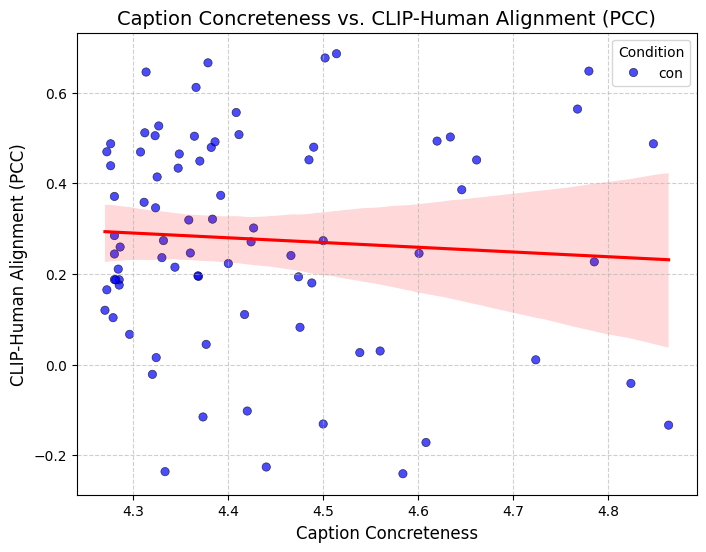

In [12]:
import seaborn as sns
from scipy.stats import linregress

# Extract concreteness scores and PCC values
concreteness_scores = [info['concrete_score'] for trial_id, info in data_all.iterrows()]
human_clip_pcc = [info['human_map_pcc'] for trial_id, info in data_all.iterrows()]
conditions = [info['condition'] for trial_id, info in data_all.iterrows()]  # 'con' or 'abs'

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Concreteness': concreteness_scores,
    'PCC': human_clip_pcc,
    'Condition': conditions
})

plot_data = plot_data[plot_data["Condition"]=="con"]

# Scatter plot with regression line
plt.figure(figsize=(8, 6))
slope, intercept, r_value, p_value, std_err = linregress(plot_data['Concreteness'], plot_data['PCC'])
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R^2: {r_value**2:.4f}, p-value: {p_value:.4e}")
sns.scatterplot(data=plot_data, x='Concreteness', y='PCC', hue='Condition', palette={'con': 'blue', 'abs': 'orange'}, alpha=0.7, edgecolor='k')
sns.regplot(data=plot_data, x='Concreteness', y='PCC', scatter=False, color='red')
plt.title('Caption Concreteness vs. CLIP-Human Alignment (PCC)', fontsize=14)
plt.xlabel('Caption Concreteness', fontsize=12)
plt.ylabel('CLIP-Human Alignment (PCC)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Condition')
plt.show()


#### Per EMHMM Group Analysis

In [25]:
# T-test analysis
for measurement in [f'map_pcc', f'word_importance_pcc', f'concatenate_pcc']:

    # Perform t-test
    t_stat, p_value = ttest_rel(data_all[f'grp1_{measurement}'], data_all[f'grp2_{measurement}'])

    print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

(map_pcc) T-statistic: 8.882123821026486, P-value: 1.329872587405734e-15
(word_importance_pcc) T-statistic: 1.632851298949246, P-value: 0.10447903966793935
(concatenate_pcc) T-statistic: 8.880445952672957, P-value: 1.3433485040387226e-15


mixed-effect model

In [28]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for trial_id, info in data_all.iterrows():
    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "trial_id": trial_id,
            "condition": info["condition"],
            "group": "grp1",
            "map_pcc": info["grp1_map_pcc"],
            "word_importance_pcc": info["grp1_word_importance_pcc"],
            "concatenate_pcc": info["grp1_concatenate_pcc"]
        }, {
            "trial_id": trial_id,
            "condition": info["condition"],
            "group": "grp2",
            "map_pcc": info["grp2_map_pcc"],
            "word_importance_pcc": info["grp2_word_importance_pcc"],
            "concatenate_pcc": info["grp2_concatenate_pcc"]
        }])
    ], ignore_index=True)

# Display the prepared long format DataFrame
long_format_data

,trial_id,condition,group,map_pcc,word_importance_pcc,concatenate_pcc
0,matched_abs_COCO_val2014_000000057495.jpg,abs,grp1,0.221606,0.419091,0.221658
1,matched_abs_COCO_val2014_000000057495.jpg,abs,grp2,0.069581,0.555641,0.069731
2,matched_con_COCO_val2014_000000057495.jpg,con,grp1,0.120399,0.080898,0.120457
3,matched_con_COCO_val2014_000000057495.jpg,con,grp2,0.021252,0.253547,0.021385
4,matched_abs_COCO_val2014_000000314426.jpg,abs,grp1,0.575622,0.192268,0.575586
...,...,...,...,...,...,...
315,matched_con_COCO_val2014_000000320743.jpg,con,grp2,0.067415,0.673102,0.067645
316,matched_abs_COCO_val2014_000000098658.jpg,abs,grp1,0.281409,0.575753,0.281457
317,matched_abs_COCO_val2014_000000098658.jpg,abs,grp2,0.072988,0.545706,0.073056
318,matched_con_COCO_val2014_000000098658.jpg,con,grp1,0.194710,0.546490,0.194834


In [41]:
import pandas as pd
import statsmodels.formula.api as smf

for measurement in ['map_pcc', 'word_importance_pcc', 'concatenate_pcc']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    model = smf.mixedlm(f"{measurement} ~ group * condition", long_format_data, groups="trial_id")
    result = model.fit()
    print(result.summary())

Mixed-Effect Model Analysis for map_pcc:
                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       map_pcc 
No. Observations:        320           Method:                   REML    
No. Groups:              160           Scale:                    0.0023  
Min. group size:         2             Log-Likelihood:           202.9625
Max. group size:         2             Converged:                Yes     
Mean group size:         2.0                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       0.287    0.026 11.130 0.000  0.237  0.338
group[T.grp2]                  -0.047    0.008 -6.202 0.000 -0.061 -0.032
condition[T.con]               -0.008    0.036 -0.212 0.832 -0.079  0.064
group[T.grp2]:c

## Interpreting EMHMM Groups
Exploring more fixations on the image?

In [38]:
for trial_id, info in data_all.iterrows():
    
    # number of fixations on image; for confirming interpretations on EMHMM group
    # explorting strategy -> more fixations?
    for group in ['grp1', 'grp2']:
        fixations = pd.read_excel(f"../../results/{analysis_name}/{group}/image/fixations/{trial_id}.xlsx")
        data_all.at[trial_id, f'{group}_emap_var'] = np.var(info[f'{group}_map'])
        data_all.at[trial_id, f'{group}_image_fixations_num'] = len(fixations)

In [39]:
for measurement in ['emap_var', 'image_fixations_num']:

    t_stat, p_value = ttest_rel(data_all[f'grp1_{measurement}'], data_all[f'grp2_{measurement}'])

    print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

(emap_var) T-statistic: 7.937610245167455, P-value: 3.488339337842698e-13
(image_fixations_num) T-statistic: 45.4024732188378, P-value: 6.1166662653967184e-93
